# SASHIMI-C: usage walkthrough

## Goal
Create a small CDM population from the standard API, inspect and export its
named weighted catalog, and calculate existing observables. These are bounded
teaching grids; scientific convergence is evaluated in a separate notebook.

## Setup
Use Python 3.11–3.13 and the candidate `sashimi-itamae` and `sashimi-c` wheels
from the review wheelhouse. Install the demo extras and use that environment's
kernel. The release candidate has not been published to PyPI.


In [1]:
import tempfile
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from itamae.provenance import source_revision

import itamae
import sashimi_c
packages = [('sashimi-itamae', 'itamae', itamae.__file__), ('sashimi-c', 'sashimi-c', sashimi_c.__file__)]
display({distribution: {'version': version(distribution), 'source_revision': source_revision(component, module_file=module_file)} for distribution, component, module_file in packages})
workspace = tempfile.TemporaryDirectory(prefix='sashimi-c-walkthrough-')
work = Path(workspace.name)


{'sashimi-itamae': {'version': '0.2.0rc1',
  'source_revision': 'dfa083d0d46181c376947ac7b2da829facaf2e8b'},
 'sashimi-c': {'version': '2.0.0rc1',
  'source_revision': '69842655089d90e8d45d4b283a3f431425eed765'}}

## Steps: configure and evolve a CDM catalog
Masses are numerical solar masses; catalog radii are Mpc and densities are
Msun/Mpc³. Solver and disruption choices remain explicit.

In [2]:
from sashimi_c import subhalo_observables, subhalo_properties

parameters = {
    'M0': 1e12, 'redshift': 0.0, 'dz': 0.5, 'zmax': 2.0,
    'N_ma': 24, 'sigmalogc': 0.128, 'N_herm': 3,
    'logmamin': 6.0, 'logmamax': 10.0, 'N_hermNa': 8,
    'Na_model': 3, 'ct_th': 0.0, 'method': 'pert2_shanks',
    'profile_change': True,
}
model = subhalo_properties()
catalog = model.subhalo_catalog_calc(**parameters)
print('nodes:', len(catalog), 'expected surviving count:', catalog.weight_final.sum())


nodes: 288 expected surviving count: 6126.021831907502


## Inspect, select, and plot the weighted catalogue
Rows are quadrature nodes; `weight_final` is the effective population count.


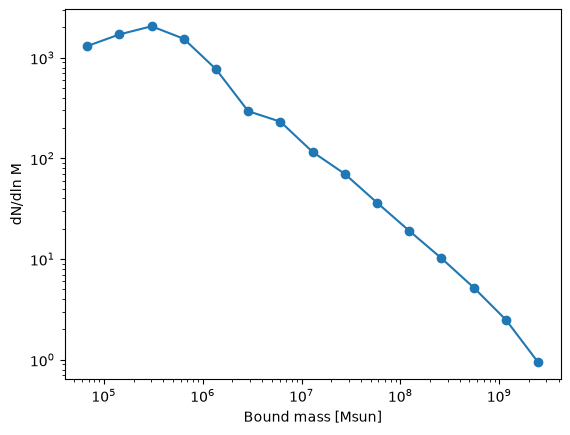

mappingproxy({'schema_version': '1.0',
              'model_identifier': 'sashimi-c:cdm:2026-09-10:v1',
              'backend_identifier': 'array=numpy;cosmology=native-flatlcdm:Om=0.315:h=0.674;units=canonical-Msun-Mpc-km-s',
              'cosmology_backend': 'native-flatlcdm:Om=0.315:h=0.674',
              'cosmology_parameters': {'omega_m0': 0.315,
               'h': 0.674,
               'omega_lambda0': 0.685},
              'canonical_units': {'mass': 'Msun',
               'length': 'Mpc',
               'velocity': 'km / s',
               'density': 'Msun / Mpc3'},
              'critical_density_convention': 'itamae-backend',
              'host_mass_input': 1000000000000.0,
              'host_mass_z0': 1000000000000.0,
              'host_mass_input_at_target_redshift': False,
              'target_redshift': 0.0,
              'zmax': 2.0,
              'dz': 0.5,
              'n_mass': 24,
              'n_concentration': 3,
              'n_host_history': 8,
       

weighted bound mass: 18103956723.967888


In [3]:
from itamae.types import WeightedSubhaloCatalog

if not np.all(np.isfinite(catalog.weight_final)) or np.any(catalog.weight_final < 0):
    raise RuntimeError('Invalid catalogue weights')
mass = np.asarray(catalog.columns['m_bound'])
positive = (mass > 0) & (catalog.weight_final > 0)
selected = catalog.select(positive)
edges = np.geomspace(mass[positive].min() * 0.99, mass[positive].max() * 1.01, 16)
counts, edges = selected.weighted_histogram('m_bound', bins=edges)
centres = np.sqrt(edges[:-1] * edges[1:])
density = counts / np.diff(np.log(edges))
plt.loglog(centres, density, marker='o')
plt.xlabel('Bound mass [Msun]')
plt.ylabel('dN/dln M')
plt.show()
display(catalog.metadata)
print('weighted bound mass:', selected.weighted_sum(selected.columns['m_bound']))


## Export and restore the catalogue


In [4]:
path = work / 'catalog.npz'
catalog.to_npz(path)
restored = WeightedSubhaloCatalog.from_npz(path)
for name in catalog.columns:
    np.testing.assert_array_equal(restored.columns[name], catalog.columns[name])
np.testing.assert_array_equal(restored.weight_final, catalog.weight_final)
print(path)


/tmp/sashimi-c-walkthrough-340ij8ss/catalog.npz


## Observable-facing mass functions


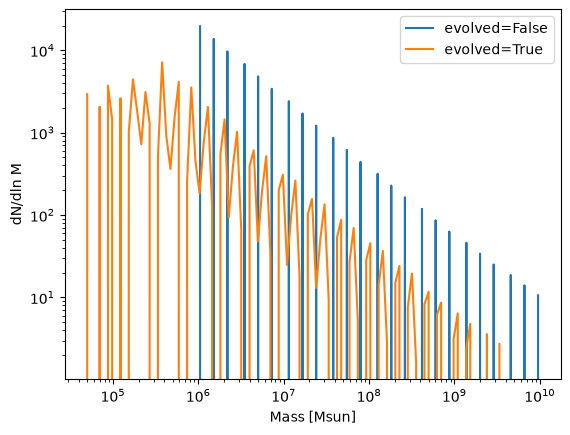

In [5]:
obs_parameters = {('M0_per_Msun' if key == 'M0' else key): value for key, value in parameters.items()}
observables = subhalo_observables(**obs_parameters)
for evolved in (False, True):
    mass_axis, density = observables.mass_function(evolved=evolved)
    if not np.all(np.isfinite(density)):
        raise RuntimeError('Mass function contains non-finite values')
    plt.loglog(mass_axis, density, label=f'evolved={evolved}')
plt.legend()
plt.xlabel('Mass [Msun]')
plt.ylabel('dN/dln M')
plt.show()


## Checks and next steps
The catalog weights are finite and nonnegative, and the NPZ round trip preserves
all columns and final weights. The standard API uses a single versioned
calculation specification; `physics_mode` is removed. Historical reproduction
uses the separate frozen A/B workflow in sashimi-family.

These plots demonstrate API usage, not numerical convergence or a simulation
calibration. The scientific comparison notebook records B/C agreement and the
solver/grid checks. Prompt-cusp calculations require external spectra documented
in the migration guide; their scientific validation is deferred by agreement.